In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime

In [2]:
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")

In [3]:
CARIACO.columns

Index(['Unnamed: 0', 'tauoc', 'sst', 'sp', 'u10', 'v10', 'lsm', 'si10', 'ewss',
       'e', 'ro', 'tp', 'mtpr', 'time_month', 'O2_umol_kg', 'O2_ml_L',
       'NO3_UDO', 'PO4_UDO', 'SiO4_UDO', 'NH4_USF', 'NO2_USF', 'NO3_NO2_USF',
       'NO3_USF', 'PO4_USF', 'SiO4_USF', 'NO3_merged', 'PO4_merged',
       'SiO4_merged', 'pH_corrected', 'Salinity_bottles', 'Temperature',
       'Sigma_t', 'PrimaryProductivity', 'Chlorophyll', 'Phaeopigments',
       'source', 'Pras', 'Lut', 'Fuco', 'Perid', 'Allo', 'But_fuco',
       'Hex_fuco', 'Zea', 'Tot_Chl_b', 'DP', 'Tot_Chl_a', 'TChl', 'Chl_c1c2',
       'Chl_c3', 'DP2', 'micro', 'nano', 'pico', 'Mesh200', 'Mesh500',
       'Isotherm_21', 'MLD', 'SST', 'ui', 'upwelling', 'euphotic_depth'],
      dtype='object')

In [4]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

CARIACO.ui = CARIACO.ui.astype('category').cat.reorder_categories(['relaxed', 'weak','moderate', 'strong'])

CARIACO.upwelling = CARIACO.upwelling.astype('category').cat.reorder_categories(['relaxed', 'upwelling'])

In [5]:
Fish = pd.read_csv("../DATA/processed/fisheries.csv")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
Fish.columns

Index(['Unnamed: 0', 'year', 'sardinelandings', 'date'], dtype='object')

In [6]:

cluster1_mask = (CARIACO.date.dt.date>datetime.date(1996, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2003, 12, 31)) | \
                 (CARIACO.date.dt.date>datetime.date(2014, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2016, 12, 31))

cluster2_mask = (CARIACO.date.dt.date>datetime.date(2004, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2013, 12, 31))

CARIACO["cluster"] = 'none'
CARIACO.loc[cluster1_mask, "cluster"] = 'cluster 1'
CARIACO.loc[cluster2_mask, "cluster"] = 'cluster 2'

# Version 1 - two rows of boxplots

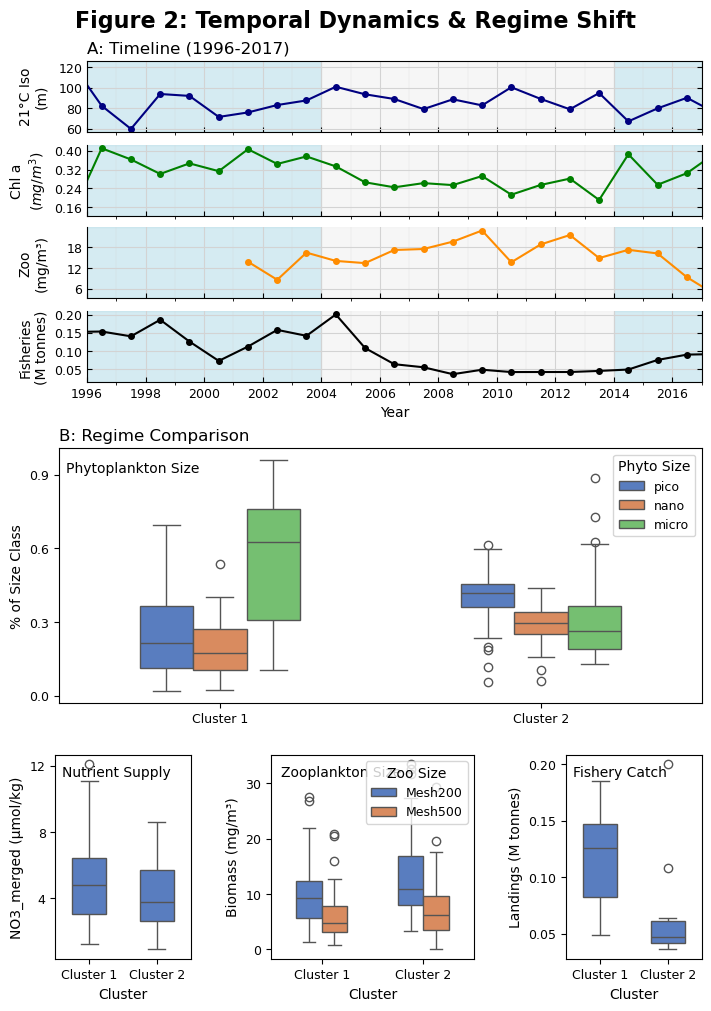

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
fig = plt.figure(figsize=(7, 10), constrained_layout=True)
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

gs_main = fig.add_gridspec(2, 1, height_ratios=[4, 6])
gs_top = gs_main[0].subgridspec(4, 1, hspace=0) 

axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
axC = fig.add_subplot(gs_top[2, 0], sharex=axA)
axD = fig.add_subplot(gs_top[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

gs_bottom = gs_main[1].subgridspec(2, 1, hspace=0.1)
axF = fig.add_subplot(gs_bottom[0, 0]) # Phyto
axF.set_title("B: Regime Comparison", fontsize=12, loc='left')

gs_bottom_row2 = gs_bottom[1, 0].subgridspec(1, 3, 
                                            wspace=0.15, 
                                            width_ratios=[2, 3, 2])
axE = fig.add_subplot(gs_bottom_row2[0, 0]) # Nutrient
axG = fig.add_subplot(gs_bottom_row2[0, 1], sharex=axE) # Zoo
axH = fig.add_subplot(gs_bottom_row2[0, 2], sharex=axE) # Fisheries

# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data (MODIFIED: two-line y-labels)
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)")
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)")
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)")
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)")
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in")
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# Remove top spines to close vertical gap
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")

# Top row: Phyto
# MODIFIED: width=0.5, show x-tick labels
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=0.5)
axF.set_ylabel("% of Size Class")
axF.legend(title='Phyto Size', loc='upper right')
axF.set_xlabel("") # No x-label on top row
# plt.setp(axF.get_xticklabels(), visible=False) # MODIFIED: Show x-tick labels
axF.text(0.01, 0.95, "Phytoplankton Size", transform=axF.transAxes, va='top', ha='left', fontsize=10)
axF.get_yaxis().set_major_locator(MaxNLocator(nbins=4))

# Bottom row: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=0.5)
axE.set_ylabel("NO3_merged (µmol/kg)")
axE.text(0.05, 0.95, "Nutrient Supply", transform=axE.transAxes, va='top', ha='left', fontsize=10)
axE.get_yaxis().set_major_locator(MaxNLocator(nbins=4))

# Bottom row: Zooplankton
# MODIFIED: width=0.5
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=0.5)
axG.set_ylabel("Biomass (mg/m³)")
axG.legend(title='Zoo Size', loc='upper right')
axG.text(0.05, 0.95, "Zooplankton Size", transform=axG.transAxes, va='top', ha='left', fontsize=10)
axG.get_yaxis().set_major_locator(MaxNLocator(nbins=4))

# Bottom row: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=0.5)
axH.set_ylabel("Landings (M tonnes)")
axH.text(0.05, 0.95, "Fishery Catch", transform=axH.transAxes, va='top', ha='left', fontsize=10)
axH.get_yaxis().set_major_locator(MaxNLocator(nbins=4))

# Format bottom row axes
for ax in [axE, axG, axH]:
    ax.set_xlabel("Cluster")
    
# --- 7. Show Plot ---
plt.show()

# Version 2 - Boxplots in a single ROW

/Users/aoop/micromamba/envs/xso2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


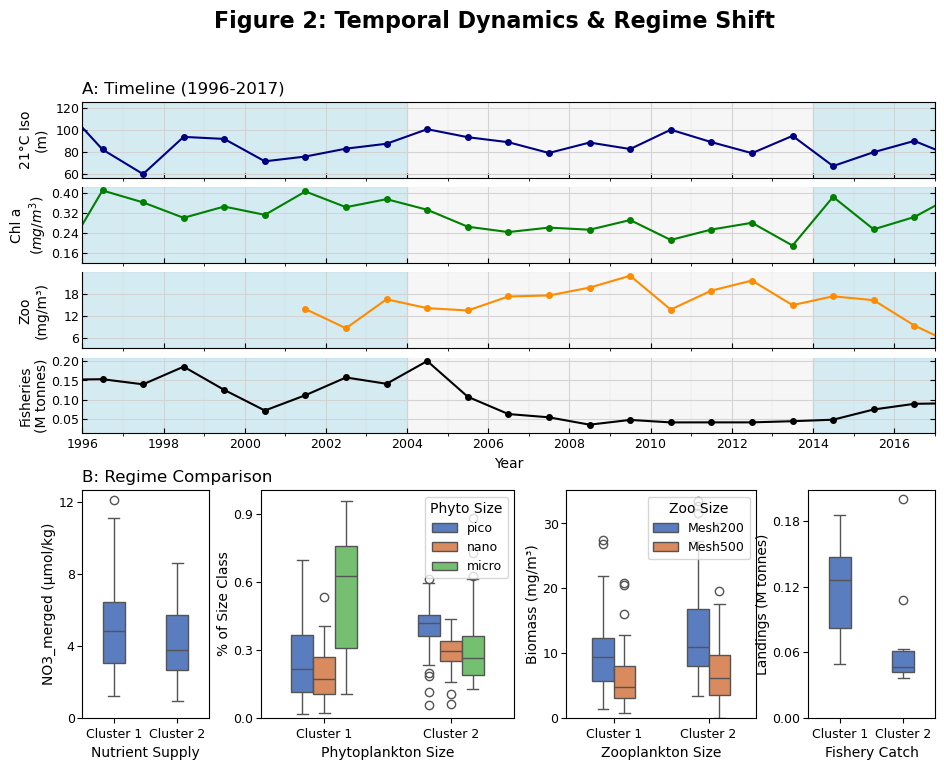

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean # Import gmean

# --- 0. Set Plotting Style ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']

# Convert fisheries to millions of tonnes
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 2b. Calculate Yearly Geometric Means ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# Resample to yearly frequency and apply safe geometric mean
yearly_cariaco = CARIACO.resample('YE', on='date').agg({
    'Isotherm_21': safe_gmean,
    'Chlorophyll': safe_gmean,
    'Zoo_Total': safe_gmean
}).reset_index()

# Create 'plot_date' at the middle of the year (July 1st)
yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)

# Nudge fish data to mid-year
Fish['plot_date'] = Fish['date'] + pd.DateOffset(months=6)


# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure ---
fig = plt.figure(figsize=(11, 8), constrained_layout=True) 
fig.suptitle('Figure 2: Temporal Dynamics & Regime Shift', fontsize=16, weight='bold')

# MODIFIED: 6 rows, hspace=0, and new height_ratios with a spacer
gs_main = fig.add_gridspec(6, 4, 
                           height_ratios=[1, 1, 1, 1, 0.5, 3], # Row 5 is the spacer
                           width_ratios=[2, 4, 3, 2],
                           wspace=0.3, hspace=0.1)

# --- Top Panel: Timelines (Rows 0-3) ---
axA = fig.add_subplot(gs_main[0, :])
axB = fig.add_subplot(gs_main[1, :], sharex=axA)
axC = fig.add_subplot(gs_main[2, :], sharex=axA)
axD = fig.add_subplot(gs_main[3, :], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# --- Bottom Panel: 1 row, 4 plots (Row 5) ---
# Row 4 (gs_main[4, :]) is left empty
axE = fig.add_subplot(gs_main[5, 0]) # Nutrient
axF = fig.add_subplot(gs_main[5, 1]) # Phyto
axG = fig.add_subplot(gs_main[5, 2]) # Zoo
axH = fig.add_subplot(gs_main[5, 3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]


# --- 5. Plot Top Panel (Timelines) ---
axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", labelpad=2)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n($mg/m^3$)", labelpad=2)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", labelpad=2)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", labelpad=2)
axD.set_xlabel("Year")

# Apply user-specific styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", axis='y', pad=2)
    ax.tick_params(top=False, right=True, direction="in", axis='x')
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)
fig.align_ylabels(timeline_axes)

# MODIFIED: Re-enabled spine removal
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)


# --- 6. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

# Keep boxes legible
box_width = 0.35 

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='NO3_merged', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("NO3_merged (µmol/kg)", labelpad=2)
axE.set_xlabel("Nutrient Supply") 

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 1.5)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) 
axF.set_xlabel("Phytoplankton Size") 

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 1.3)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) 
axG.set_xlabel("Zooplankton Size") 

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") 
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 1]) 
    ax.set_xticklabels(["Cluster 1", "Cluster 2"])

    
# --- 7. Show Plot ---
plt.show()

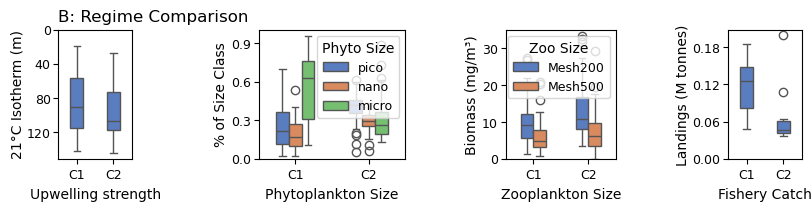

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import datetime
from matplotlib.ticker import MaxNLocator

# --- 0. Set Plotting Style (Exact copy) ---
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# --- 1. Load Data ---
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")
Fish = pd.read_csv("../DATA/processed/fisheries.csv")

# --- 2. Process Data ---
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
CARIACO['Zoo_Total'] = CARIACO['Mesh200'] + CARIACO['Mesh500']
Fish['sardinelandings_M'] = Fish['sardinelandings'] / 1_000_000

# --- 3. Define and Assign Clusters ---
c1_ranges = [
    (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
    (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
]
c2_ranges = [
    (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
]

# Assign clusters to CARIACO
CARIACO['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (CARIACO['date'].dt.date >= start) & (CARIACO['date'].dt.date <= end)
    CARIACO.loc[mask, 'cluster'] = 'Cluster 2'

# Assign clusters to Fish
Fish['cluster'] = 'none'
for start, end in c1_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 1'
for start, end in c2_ranges:
    mask = (Fish['date'].dt.year >= start.year) & (Fish['date'].dt.year <= end.year)
    Fish.loc[mask, 'cluster'] = 'Cluster 2'

# Filter and melt data for boxplots
cariaco_clusters = CARIACO[CARIACO['cluster'] != 'none'].copy()
fish_clusters = Fish[Fish['cluster'] != 'none'].copy()
cluster_order = ['Cluster 1', 'Cluster 2']

melt_phyto = pd.melt(cariaco_clusters, id_vars='cluster', 
                     value_vars=['pico', 'nano', 'micro'], 
                     var_name='Phyto Size')
melt_zoo = pd.melt(cariaco_clusters, id_vars='cluster', 
                   value_vars=['Mesh200', 'Mesh500'], 
                   var_name='Zoo Size')

# --- 4. Create the Figure (Panel B Only) ---
# Height reduced to 4 since we removed the top panel
fig = plt.figure(figsize=(8, 2), constrained_layout=True) 

# Use GridSpec to maintain the EXACT width ratios from original code
gs_main = fig.add_gridspec(1, 4, width_ratios=[2, 4, 3, 2], wspace=0.3)

axE = fig.add_subplot(gs_main[0]) # Nutrient
axF = fig.add_subplot(gs_main[1]) # Phyto
axG = fig.add_subplot(gs_main[2]) # Zoo
axH = fig.add_subplot(gs_main[3]) # Fisheries
boxplot_axes = [axE, axF, axG, axH]

# --- 5. Plot Bottom Panel (Boxplots) ---
sns.set_palette("muted")
axE.set_title("B: Regime Comparison", fontsize=12, loc='left')

box_width = 0.35 

# Plot 1: Nutrients
sns.boxplot(data=cariaco_clusters, x='cluster', y='Isotherm_21', order=cluster_order, ax=axE, width=box_width)
axE.set_ylabel("21°C Isotherm (m)", labelpad=2)
axE.set_xlabel("Upwelling strength") 

# Plot 2: Phyto
sns.boxplot(data=melt_phyto, x='cluster', y='value', hue='Phyto Size', order=cluster_order, ax=axF, width=box_width * 1.5)
axF.legend(title='Phyto Size', loc='upper right')
axF.set_ylabel("% of Size Class", labelpad=2) 
axF.set_xlabel("Phytoplankton Size") 

# Plot 3: Zooplankton
sns.boxplot(data=melt_zoo, x='cluster', y='value', hue='Zoo Size', order=cluster_order, ax=axG, width=box_width * 1.3)
axG.legend(title='Zoo Size', loc='upper right')
axG.set_ylabel("Biomass (mg/m³)", labelpad=2) 
axG.set_xlabel("Zooplankton Size") 

# Plot 4: Fisheries
sns.boxplot(data=fish_clusters, x='cluster', y='sardinelandings_M', order=cluster_order, ax=axH, width=box_width)
axH.set_ylabel("Landings (M tonnes)", labelpad=2)
axH.set_xlabel("Fishery Catch") 
axH.yaxis.tick_left() 
axH.yaxis.set_label_position("left")

# Format all boxplot axes
for ax in boxplot_axes:
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='y', pad=2)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 1]) 
    ax.set_xticklabels(["C1", "C2"])

axE.invert_yaxis()
# --- 6. Show Plot ---
plt.savefig("PartialFigure_RegimeComp_ISOTHERM.pdf")
plt.show()